# GCON EDA And Model Input Build

This notebook owns data loading, full feature engineering, subscription label creation, EDA views,
and export of the single model input file:
`NBFO_IB/processed_data/gcon_model_input.parquet`.

## 1. Setup

Define paths, constants, and the product mapping used throughout the pipeline.

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 120)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'NBFO_IB':
    PROJECT_ROOT = PROJECT_ROOT.parent

NBFO_DIR = PROJECT_ROOT / 'NBFO_IB'
CLEAN_DIR = PROJECT_ROOT / 'cleaned_data'
OUTPUT_DIR = NBFO_DIR / 'processed_data'
MASTER_PATH = OUTPUT_DIR / 'gcon_customer_month_clean.parquet'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

HORIZON = 2
RANDOM_STATE = 42

PRODUCTS = pd.DataFrame([
    {'PRODUCT_CODE': 101, 'PRODUCT_NAME': 'CURRENT_ACCOUNT', 'OWN_COL': 'OWN_CURRENT_ACCOUNT'},
    {'PRODUCT_CODE': 102, 'PRODUCT_NAME': 'TERM_DEPOSIT', 'OWN_COL': 'OWN_TERM_DEPOSIT'},
    {'PRODUCT_CODE': 103, 'PRODUCT_NAME': 'CREDIT_CARD', 'OWN_COL': 'OWN_CREDIT_CARD'},
    {'PRODUCT_CODE': 104, 'PRODUCT_NAME': 'DEBIT_CARD', 'OWN_COL': 'OWN_DEBIT_CARD'},
    {'PRODUCT_CODE': 105, 'PRODUCT_NAME': 'LENDING', 'OWN_COL': 'OWN_LENDING'},
])

PRODUCTS

,PRODUCT_CODE,PRODUCT_NAME,OWN_COL
0,101,CURRENT_ACCOUNT,OWN_CURRENT_ACCOUNT
1,102,TERM_DEPOSIT,OWN_TERM_DEPOSIT
2,103,CREDIT_CARD,OWN_CREDIT_CARD
3,104,DEBIT_CARD,OWN_DEBIT_CARD
4,105,LENDING,OWN_LENDING


## 2. Utility Functions



In [2]:
def ensure_numeric(df, cols):
    for col in cols:
        if col not in df.columns:
            df[col] = 0
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    return df


def downcast_numeric(df):
    for col in df.select_dtypes(include=['int64', 'Int64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='float')
    return df


def save_parquet(df, path):
    path = Path(path)
    path.parent.mkdir(exist_ok=True)
    df.to_parquet(path, index=False)
    print('saved', path, df.shape)


def show_bar_labels(ax, fmt='{:.1%}'):
    for container in ax.containers:
        labels = []
        for val in container.datavalues:
            labels.append(fmt.format(val) if abs(val) <= 1 else f'{val:,.0f}')
        ax.bar_label(container, labels=labels, padding=3, fontsize=8)


def month_diff(later, earlier):
    return (later.dt.year - earlier.dt.year) * 12 + (later.dt.month - earlier.dt.month)

## 3. Load IB Customer-Month Data



In [3]:
required_tables = [
    'customer_clean', 'deposit_clean', 'lending_clean', 'card_clean', 'transaction_clean', 'activity_clean'
]
missing = [name for name in required_tables if not (CLEAN_DIR / f'{name}.parquet').exists()]
if missing:
    raise FileNotFoundError(f'Missing clean component tables: {missing}. Run clean.ipynb first.')

customer_clean = pd.read_parquet(CLEAN_DIR / 'customer_clean.parquet')
deposit_clean = pd.read_parquet(CLEAN_DIR / 'deposit_clean.parquet')
lending_clean = pd.read_parquet(CLEAN_DIR / 'lending_clean.parquet')
card_clean = pd.read_parquet(CLEAN_DIR / 'card_clean.parquet')
transaction_clean = pd.read_parquet(CLEAN_DIR / 'transaction_clean.parquet')
activity_clean = pd.read_parquet(CLEAN_DIR / 'activity_clean.parquet')

for df in [deposit_clean, lending_clean, card_clean, transaction_clean, activity_clean]:
    df['MONTH'] = pd.to_datetime(df['MONTH'], errors='coerce').dt.to_period('M').dt.to_timestamp('M')
for col in ['CLIENT_CREATE_DATE', 'DATE_OF_BIRTH', 'IB_REGISTER_DATE']:
    customer_clean[col] = pd.to_datetime(customer_clean[col], errors='coerce')
transaction_clean['TRANS_DATE'] = pd.to_datetime(transaction_clean['TRANS_DATE'], errors='coerce')
activity_clean['ACTIVITY_DATE'] = pd.to_datetime(activity_clean['ACTIVITY_DATE'], errors='coerce')

transaction_monthly = (
    transaction_clean
    .groupby(['CUSTOMER_NUMBER', 'MONTH'], as_index=False)
    .agg(
        TRANS_RECORDS=('TRANS_NO', 'size'),
        TRANS_NO_SUM=('TRANS_NO', 'sum'),
        TRANS_AMOUNT_SUM=('TRANS_AMOUNT', 'sum'),
        TRANS_AMOUNT_MEAN=('TRANS_AMOUNT', 'mean'),
        TRANS_AMOUNT_MAX=('TRANS_AMOUNT', 'max'),
        TRANS_ACTIVE_DAYS=('TRANS_DATE', 'nunique'),
        TRANS_TYPE_LV1_NUNIQUE=('TRANS_LV1', 'nunique'),
        TRANS_TYPE_LV2_NUNIQUE=('TRANS_LV2', 'nunique'),
        DEVICE_NUNIQUE=('Device_ID_Hash', 'nunique'),
        MERCHANT_NUNIQUE=('Merchant_ID_Masked', 'nunique'),
        INTERNAL_TRANSFER_ROWS=('IS_INTERNAL_TRANSFER', 'sum'),
    )
)
transaction_monthly = downcast_numeric(transaction_monthly)

activity_monthly = (
    activity_clean
    .groupby(['CUSTOMER_NUMBER', 'MONTH'], as_index=False)
    .agg(
        ACTIVITY_RECORDS=('ACTIVITY_NO', 'size'),
        ACTIVITY_NO_SUM=('ACTIVITY_NO', 'sum'),
        ACTIVITY_ACTIVE_DAYS=('ACTIVITY_DATE', 'nunique'),
        ACTIVITY_NAME_NUNIQUE=('ACTIVITY_NAME', 'nunique'),
        ACTIVITY_HOUR_NUNIQUE=('ACTIVITY_HOUR', 'nunique'),
    )
)

activity_type_counts = (
    activity_clean
    .groupby(['CUSTOMER_NUMBER', 'MONTH', 'ACTIVITY_NAME'], as_index=False)
    .size()
    .rename(columns={'size': 'ACT_COUNT'})
)

if not activity_type_counts.empty:
    activity_type_pivot = (
        activity_type_counts
        .pivot_table(
            index=['CUSTOMER_NUMBER', 'MONTH'],
            columns='ACTIVITY_NAME',
            values='ACT_COUNT',
            fill_value=0,
        )
        .reset_index()
    )
    activity_type_pivot.columns = [
        col if col in ['CUSTOMER_NUMBER', 'MONTH']
        else 'ACTIVITY_TYPE_COUNT_' + re.sub(r'[^0-9A-Z]+', '_', str(col).upper())
        for col in activity_type_pivot.columns
    ]
    activity_monthly = activity_monthly.merge(
        activity_type_pivot, on=['CUSTOMER_NUMBER', 'MONTH'], how='left'
    )
    type_count_cols = [c for c in activity_monthly.columns if c.startswith('ACTIVITY_TYPE_COUNT_')]
    activity_monthly[type_count_cols] = activity_monthly[type_count_cols].fillna(0)

activity_monthly = downcast_numeric(activity_monthly)

monthly_keys = pd.concat([
    deposit_clean[['CUSTOMER_NUMBER', 'MONTH']],
    lending_clean[['CUSTOMER_NUMBER', 'MONTH']],
    card_clean[['CUSTOMER_NUMBER', 'MONTH']],
    transaction_monthly[['CUSTOMER_NUMBER', 'MONTH']],
    activity_monthly[['CUSTOMER_NUMBER', 'MONTH']],
], ignore_index=True).drop_duplicates()

base = monthly_keys.merge(customer_clean, on='CUSTOMER_NUMBER', how='left')
base = base.merge(deposit_clean, on=['CUSTOMER_NUMBER', 'MONTH'], how='left')
base = base.merge(lending_clean, on=['CUSTOMER_NUMBER', 'MONTH'], how='left')
base = base.merge(card_clean, on=['CUSTOMER_NUMBER', 'MONTH'], how='left')
base = base.merge(transaction_monthly, on=['CUSTOMER_NUMBER', 'MONTH'], how='left')
base = base.merge(activity_monthly, on=['CUSTOMER_NUMBER', 'MONTH'], how='left')

fill_zero_prefixes = (
    'COUNT_', 'AVG_', 'OVERDUE_', 'LIMIT_', 'OUTSTANDING_', 'TERM_', 'INTEREST_',
    'TRANS_', 'ACTIVITY_', 'DEVICE_', 'MERCHANT_', 'INTERNAL_'
)
fill_zero_cols = [c for c in base.columns if c.startswith(fill_zero_prefixes)]
base[fill_zero_cols] = base[fill_zero_cols].fillna(0)

base = base.sort_values(['CUSTOMER_NUMBER', 'MONTH']).reset_index(drop=True)
base = downcast_numeric(base)
base['CUSTOMER_NUMBER'] = pd.to_numeric(base['CUSTOMER_NUMBER'], errors='coerce').astype('Int64')
base = base.dropna(subset=['CUSTOMER_NUMBER', 'MONTH']).copy()
base['HAS_IB'] = base['IB_REGISTER_DATE'].notna().astype('int8')
ib_base = base.query('HAS_IB == 1').copy()

MASTER_PATH.parent.mkdir(parents=True, exist_ok=True)
try:
    base.to_parquet(MASTER_PATH, index=False)
    base.to_csv(OUTPUT_DIR / 'gcon_customer_month_clean.csv', index=False)
    print('saved master', MASTER_PATH, base.shape)
except PermissionError as exc:
    print(f'skipped master export because file is locked: {MASTER_PATH} ({exc})')

scope = pd.DataFrame({
    'metric': ['all_customer_month_rows', 'all_customers', 'ib_customer_month_rows', 'ib_customers', 'min_month', 'max_month'],
    'value': [len(base), base['CUSTOMER_NUMBER'].nunique(), len(ib_base), ib_base['CUSTOMER_NUMBER'].nunique(), ib_base['MONTH'].min(), ib_base['MONTH'].max()],
})
display(scope)
display(ib_base.head())

saved master c:\Users\bumbu\Documents\gconlap\gcon\NBFO_IB\processed_data\gcon_customer_month_clean.parquet (1526077, 40)


,metric,value
0,all_customer_month_rows,1526077
1,all_customers,260453
2,ib_customer_month_rows,887822
3,ib_customers,154291
4,min_month,2019-01-31 00:00:00
5,max_month,2019-12-31 00:00:00


,CUSTOMER_NUMBER,MONTH,CLIENT_SEX,CLIENT_CREATE_DATE,DATE_OF_BIRTH,STAFF,IB_REGISTER_DATE,EB_REGISTER_CHANNEL,SMS,VERIFY_METHOD,AGE,Occupation_Group,Education_Level,Marital_Status,COUNT_CA_ACCT,AVG_CA_BALANCE,COUNT_TD_ACCT,AVG_TD_BALANCE,COUNT_OF_LOAN,AVG_LOAN_AMOUNT,COUNT_CREDITCARD,COUNT_DEBITCARD,TRANS_RECORDS,TRANS_NO_SUM,TRANS_AMOUNT_SUM,TRANS_AMOUNT_MEAN,TRANS_AMOUNT_MAX,TRANS_ACTIVE_DAYS,TRANS_TYPE_LV1_NUNIQUE,TRANS_TYPE_LV2_NUNIQUE,DEVICE_NUNIQUE,MERCHANT_NUNIQUE,INTERNAL_TRANSFER_ROWS,ACTIVITY_RECORDS,ACTIVITY_NO_SUM,ACTIVITY_ACTIVE_DAYS,ACTIVITY_NAME_NUNIQUE,ACTIVITY_HOUR_NUNIQUE,ACTIVITY_TYPE_COUNT_MB_INTEREST_RATE_VIEW,HAS_IB
0,0,2019-09-30,F,2019-09-16,1988-10-08,N,2019-09-17,BRANCH,N,SMART_OTP,31.230663,UNKNOWN,UNKNOWN,UNKNOWN,1.0,57364833.33,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,99800000.0,9.980000e+07,99800000.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0,2019-10-31,F,2019-09-16,1988-10-08,N,2019-09-17,BRANCH,N,SMART_OTP,31.230663,UNKNOWN,UNKNOWN,UNKNOWN,1.0,750812.90,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,2000000.0,2.000000e+06,2000000.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,0,2019-11-30,F,2019-09-16,1988-10-08,N,2019-09-17,BRANCH,N,SMART_OTP,31.230663,UNKNOWN,UNKNOWN,UNKNOWN,1.0,5280833.33,0.0,0.0,0.0,0.0,0.0,1.0,2.0,3.0,76000000.0,3.800000e+07,74000000.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0,2019-12-31,F,2019-09-16,1988-10-08,N,2019-09-17,BRANCH,N,SMART_OTP,31.230663,UNKNOWN,UNKNOWN,UNKNOWN,1.0,29460361.29,0.0,0.0,0.0,0.0,0.0,1.0,6.0,6.0,72019000.0,1.200317e+07,38000000.0,5.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,3,2019-04-30,M,2019-04-16,1987-08-15,N,2019-06-05,MYbank,Y,SMART_OTP,32.380562,UNKNOWN,UNKNOWN,UNKNOWN,0.0,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


## 4. Feature Engineering Functions



In [4]:
NUMERIC_DEFAULTS = [
    'AVG_CA_BALANCE', 'AVG_TD_BALANCE', 'COUNT_CA_ACCT', 'COUNT_TD_ACCT',
    'COUNT_CREDITCARD', 'COUNT_DEBITCARD', 'OVERDUE_CREDIT', 'LIMIT_AMT_CREDIT', 'OUTSTANDING_BAL_CREDIT',
    'COUNT_OF_LOAN', 'AVG_LOAN_AMOUNT', 'OVERDUE_LENDING', 'TERM_LENDING', 'INTEREST_RATE',
    'TRANS_RECORDS', 'TRANS_NO_SUM', 'TRANS_AMOUNT_SUM', 'TRANS_AMOUNT_MEAN', 'TRANS_AMOUNT_MAX',
    'TRANS_ACTIVE_DAYS', 'TRANS_TYPE_LV1_NUNIQUE', 'TRANS_TYPE_LV2_NUNIQUE', 'DEVICE_NUNIQUE', 'MERCHANT_NUNIQUE',
    'INTERNAL_TRANSFER_ROWS', 'ACTIVITY_RECORDS', 'ACTIVITY_NO_SUM', 'ACTIVITY_ACTIVE_DAYS',
    'ACTIVITY_NAME_NUNIQUE', 'ACTIVITY_HOUR_NUNIQUE', 'AGE'
]

PREDICTIVE_ACTIVITY_TYPES = [
    'ACTIVITY_TYPE_COUNT_QUERY_ACCOUNT_INFORMATION',
    'ACTIVITY_TYPE_COUNT_QUERY_ACCOUNT_PORFOLIO',
    'ACTIVITY_TYPE_COUNT_QUERY_CURRENT_ACCOUNT',
    'ACTIVITY_TYPE_COUNT_TRANSACTION_DETAIL_QUERY',
    'ACTIVITY_TYPE_COUNT_TRANSACTION_OVERVIEW_QUERY',
    'ACTIVITY_TYPE_COUNT_TRANSFER_BANK_ACCOUNT',
    'ACTIVITY_TYPE_COUNT_TRANSFER_VIA_PHONENO',
    'ACTIVITY_TYPE_COUNT_TRANSFER_VIA_PAYMENT_CENTER',
    'ACTIVITY_TYPE_COUNT_RB_BILLPAY_MOBILE',
    'ACTIVITY_TYPE_COUNT_TOPUP_MOBILE',
    'ACTIVITY_TYPE_COUNT_CARD_EGIFT_REGISTER_CASHBACK',
    'ACTIVITY_TYPE_COUNT_CARD_EGIFT_REGISTER_REDEEM',
    'ACTIVITY_TYPE_COUNT_EXPORT_ACCOUNT_STATEMENT_LOAN',
]

PRODUCT_HISTORY_SPECS = {
    'CURRENT_ACCOUNT': {'own': 'OWN_CURRENT_ACCOUNT', 'count': 'COUNT_CA_ACCT'},
    'TERM_DEPOSIT': {'own': 'OWN_TERM_DEPOSIT', 'count': 'COUNT_TD_ACCT'},
    'CREDIT_CARD': {'own': 'OWN_CREDIT_CARD', 'count': 'COUNT_CREDITCARD'},
    'DEBIT_CARD': {'own': 'OWN_DEBIT_CARD', 'count': 'COUNT_DEBITCARD'},
    'LENDING': {'own': 'OWN_LENDING', 'count': 'COUNT_OF_LOAN'},
}


def _activity_type_cols(df):
    return [c for c in PREDICTIVE_ACTIVITY_TYPES if c in df.columns]


def _add_ownership_flags(df):
    """Create product ownership flags and keep selected activity count inputs."""
    df = df.copy()
    all_activity_type_count_cols = sorted([c for c in df.columns if c.startswith('ACTIVITY_TYPE_COUNT_')])
    activity_type_count_cols = _activity_type_cols(df)
    df = df.drop(columns=[c for c in all_activity_type_count_cols if c not in activity_type_count_cols])
    df = ensure_numeric(df, NUMERIC_DEFAULTS + activity_type_count_cols)

    df['OWN_CURRENT_ACCOUNT'] = (df['COUNT_CA_ACCT'] > 0).astype('int8')
    df['OWN_TERM_DEPOSIT'] = (df['COUNT_TD_ACCT'] > 0).astype('int8')
    df['OWN_CREDIT_CARD'] = (df['COUNT_CREDITCARD'] > 0).astype('int8')
    df['OWN_DEBIT_CARD'] = (df['COUNT_DEBITCARD'] > 0).astype('int8')
    df['OWN_LENDING'] = ((df['COUNT_OF_LOAN'] > 0) | (df['AVG_LOAN_AMOUNT'] > 0)).astype('int8')
    return df


def _add_derived_features(df):
    """Create customer profile, balance, transaction, and behavior ratio features."""
    df = df.copy()
    own_cols = PRODUCTS['OWN_COL'].tolist()
    df['SPTC_COUNT'] = df[own_cols].sum(axis=1).astype('int8')
    df['HAS_MULTI_SPTC'] = (df['SPTC_COUNT'] >= 2).astype('int8')
    df['TOTAL_DEPOSIT_BALANCE'] = df['AVG_CA_BALANCE'] + df['AVG_TD_BALANCE']
    df['TOTAL_DEPOSIT_ACCTS'] = df['COUNT_CA_ACCT'] + df['COUNT_TD_ACCT']
    df['CARD_UTILIZATION'] = np.where(df['LIMIT_AMT_CREDIT'] > 0, df['OUTSTANDING_BAL_CREDIT'] / df['LIMIT_AMT_CREDIT'], 0)
    df['CARD_UTILIZATION'] = np.clip(df['CARD_UTILIZATION'], 0, 5)
    df['HAS_TRANSACTION'] = (df['TRANS_RECORDS'] > 0).astype('int8')
    df['HAS_ACTIVITY'] = (df['ACTIVITY_RECORDS'] > 0).astype('int8')
    df['ACTIVITY_EVENTS_PER_ACTIVE_DAY'] = np.where(df['ACTIVITY_ACTIVE_DAYS'] > 0, df['ACTIVITY_RECORDS'] / df['ACTIVITY_ACTIVE_DAYS'], 0)
    df['ACTIVITY_TYPES_PER_EVENT'] = np.where(df['ACTIVITY_RECORDS'] > 0, df['ACTIVITY_NAME_NUNIQUE'] / df['ACTIVITY_RECORDS'], 0)
    df['ACTIVITY_HOURS_PER_ACTIVE_DAY'] = np.where(df['ACTIVITY_ACTIVE_DAYS'] > 0, df['ACTIVITY_HOUR_NUNIQUE'] / df['ACTIVITY_ACTIVE_DAYS'], 0)
    df['AGE_CLEAN'] = df['AGE'].where(df['AGE'].between(16, 100))
    df['AGE_GROUP'] = pd.cut(df['AGE_CLEAN'], bins=[0, 25, 35, 45, 55, 65, 200], labels=['<=25', '26-35', '36-45', '46-55', '56-65', '65+'])
    df['CUSTOMER_TENURE_MONTHS'] = ((df['MONTH'] - pd.to_datetime(df['CLIENT_CREATE_DATE'], errors='coerce')).dt.days / 30.4375).clip(lower=0)
    df['IB_TENURE_MONTHS'] = ((df['MONTH'] - pd.to_datetime(df['IB_REGISTER_DATE'], errors='coerce')).dt.days / 30.4375).clip(lower=0)
    df['CUSTOMER_TENURE_BIN'] = pd.cut(df['CUSTOMER_TENURE_MONTHS'], bins=[-1, 3, 6, 12, 24, 48, 10000], labels=['<3m', '3-6m', '6-12m', '1-2y', '2-4y', '4y+'])
    df['ACTIVITY_SEGMENT'] = pd.cut(df['TRANS_RECORDS'], bins=[-1, 0, 5, 20, 10000000], labels=['No transaction', 'Low', 'Medium', 'High'])
    return df


def _add_rfm_features(df):
    """Create monthly RFM-style recency, frequency, and monetary features."""
    df = df.copy()
    own_cols = PRODUCTS['OWN_COL'].tolist()
    grp = df.groupby('CUSTOMER_NUMBER', sort=False)

    # MonthEnd labels are converted to a linear month index so recency can be expressed in approximate days.
    df['_MONTH_INDEX'] = df['MONTH'].dt.year * 12 + df['MONTH'].dt.month
    active_txn_month = df['_MONTH_INDEX'].where(df['TRANS_RECORDS'] > 0)
    active_login_month = df['_MONTH_INDEX'].where(df['ACTIVITY_RECORDS'] > 0)
    product_open_flag = grp[own_cols].diff().gt(0).any(axis=1)
    product_open_month = df['_MONTH_INDEX'].where(product_open_flag)

    df['_LAST_TXN_MONTH_BEFORE'] = active_txn_month.groupby(df['CUSTOMER_NUMBER']).ffill().groupby(df['CUSTOMER_NUMBER']).shift(1)
    df['_LAST_LOGIN_MONTH_BEFORE'] = active_login_month.groupby(df['CUSTOMER_NUMBER']).ffill().groupby(df['CUSTOMER_NUMBER']).shift(1)
    df['_LAST_PRODUCT_OPEN_MONTH_BEFORE'] = product_open_month.groupby(df['CUSTOMER_NUMBER']).ffill().groupby(df['CUSTOMER_NUMBER']).shift(1)

    df['DAYS_SINCE_LAST_TRANSACTION'] = ((df['_MONTH_INDEX'] - df['_LAST_TXN_MONTH_BEFORE']) * 30.4375).fillna(9999).clip(lower=0)
    df['DAYS_SINCE_LAST_LOGIN'] = ((df['_MONTH_INDEX'] - df['_LAST_LOGIN_MONTH_BEFORE']) * 30.4375).fillna(9999).clip(lower=0)
    df['DAYS_SINCE_LAST_PRODUCT_OPEN'] = ((df['_MONTH_INDEX'] - df['_LAST_PRODUCT_OPEN_MONTH_BEFORE']) * 30.4375).fillna(9999).clip(lower=0)

    df['TXN_COUNT_LAST_30D'] = df['TRANS_RECORDS']
    df['TOTAL_TRANSACTION_AMOUNT'] = df['TRANS_AMOUNT_SUM']
    df['AVG_BALANCE'] = df['TOTAL_DEPOSIT_BALANCE']
    df['TOTAL_DEPOSIT'] = df['TOTAL_DEPOSIT_BALANCE']

    df['ACTIVITY_COUNT_LAST_30D'] = df['ACTIVITY_RECORDS']
    # cumsum().shift() keeps only behavior observed before the current month to avoid contemporaneous leakage.
    df['ACTIVITY_ACTIVE_MONTHS_HISTORY'] = grp['HAS_ACTIVITY'].cumsum().groupby(df['CUSTOMER_NUMBER']).shift(fill_value=0).astype('int16')
    df['ACTIVITY_ACTIVE_MONTH_RATE_HISTORY'] = (
        grp['HAS_ACTIVITY'].expanding(min_periods=1).mean().reset_index(level=0, drop=True)
        .groupby(df['CUSTOMER_NUMBER']).shift(fill_value=0)
    )
    for col in _activity_type_cols(df):
        df[f'{col}_SHARE'] = np.where(df['ACTIVITY_RECORDS'] > 0, df[col] / df['ACTIVITY_RECORDS'], 0)
    return df


def _add_product_history(df):
    """Create product-level open, ownership duration, rate, and count history features."""
    df = df.copy()
    for product_name, spec in PRODUCT_HISTORY_SPECS.items():
        own_col = spec['own']
        count_col = spec['count']
        open_col = f'PRODUCT_OPEN_FLAG_{product_name}'

        df[open_col] = df.groupby('CUSTOMER_NUMBER', sort=False)[own_col].diff().gt(0).astype('int8')
        first_observed_open = (df.groupby('CUSTOMER_NUMBER', sort=False).cumcount() == 0) & (df[own_col] == 1)
        df.loc[first_observed_open, open_col] = 1

        open_month = df['_MONTH_INDEX'].where(df[open_col] == 1)
        last_open_before = open_month.groupby(df['CUSTOMER_NUMBER']).ffill().groupby(df['CUSTOMER_NUMBER']).shift(1)
        df[f'DAYS_SINCE_LAST_OPEN_{product_name}'] = ((df['_MONTH_INDEX'] - last_open_before) * 30.4375).fillna(9999).clip(lower=0)
        df[f'{product_name}_OPEN_COUNT_HISTORY'] = df.groupby('CUSTOMER_NUMBER', sort=False)[open_col].cumsum().groupby(df['CUSTOMER_NUMBER']).shift(fill_value=0).astype('int16')
        df[f'{product_name}_OWNED_MONTHS_HISTORY'] = df.groupby('CUSTOMER_NUMBER', sort=False)[own_col].cumsum().groupby(df['CUSTOMER_NUMBER']).shift(fill_value=0).astype('int16')
        df[f'{product_name}_OWN_RATE_HISTORY'] = (
            df.groupby('CUSTOMER_NUMBER', sort=False)[own_col].expanding(min_periods=1).mean().reset_index(level=0, drop=True)
            .groupby(df['CUSTOMER_NUMBER']).shift(fill_value=0)
        )
        df[f'{product_name}_COUNT_LAST_30D'] = df[count_col]

    df['PRODUCT_OPEN_COUNT_HISTORY'] = df[[f'{p}_OPEN_COUNT_HISTORY' for p in PRODUCT_HISTORY_SPECS]].sum(axis=1)
    return df


def add_customer_month_features(base):
    """Build all customer-month features from cleaned IB customer-month data."""
    df = base.sort_values(['CUSTOMER_NUMBER', 'MONTH']).copy()
    for fn in [
        _add_ownership_flags,
        _add_derived_features,
        _add_rfm_features,
        _add_product_history,
    ]:
        df = fn(df)
    df = df.drop(columns=['_MONTH_INDEX', '_LAST_TXN_MONTH_BEFORE', '_LAST_LOGIN_MONTH_BEFORE', '_LAST_PRODUCT_OPEN_MONTH_BEFORE'], errors='ignore')
    return df.replace([np.inf, -np.inf], np.nan)

## 5. Create Customer-Month Features



In [5]:
feature_df = add_customer_month_features(ib_base)
own_cols = PRODUCTS['OWN_COL'].tolist()

print('feature_df:', feature_df.shape)
display(feature_df[['CUSTOMER_NUMBER', 'MONTH', 'SPTC_COUNT', 'TOTAL_DEPOSIT_BALANCE', 'TRANS_RECORDS', 'ACTIVITY_RECORDS', 'CUSTOMER_TENURE_MONTHS', 'IB_TENURE_MONTHS']].head())
display(feature_df[own_cols + ['SPTC_COUNT', 'HAS_MULTI_SPTC']].agg(['mean']).T.rename(columns={'mean': 'row_rate'}))

feature_df: (887822, 107)


,CUSTOMER_NUMBER,MONTH,SPTC_COUNT,TOTAL_DEPOSIT_BALANCE,TRANS_RECORDS,ACTIVITY_RECORDS,CUSTOMER_TENURE_MONTHS,IB_TENURE_MONTHS
0,0,2019-09-30,2,57364833.33,1.0,0.0,0.459959,0.427105
1,0,2019-10-31,2,750812.90,1.0,0.0,1.478439,1.445585
2,0,2019-11-30,2,5280833.33,2.0,0.0,2.464066,2.431211
3,0,2019-12-31,2,29460361.29,6.0,0.0,3.482546,3.449692
4,3,2019-04-30,1,0.00,0.0,0.0,0.459959,0.000000


,row_rate
OWN_CURRENT_ACCOUNT,0.785213
OWN_TERM_DEPOSIT,0.091486
OWN_CREDIT_CARD,0.220464
OWN_DEBIT_CARD,0.493513
OWN_LENDING,0.384704
SPTC_COUNT,1.975380
HAS_MULTI_SPTC,0.811364


## 6. Subscription Label & Features Functions



In [6]:
def make_subscription_long(feature_df):
    own_cols = PRODUCTS['OWN_COL'].tolist()
    keys = feature_df[['CUSTOMER_NUMBER', 'MONTH']].drop_duplicates().copy()
    keys['_key'] = 1
    products = PRODUCTS.copy()
    products['_key'] = 1
    long_keys = keys.merge(products, on='_key', how='outer').drop(columns='_key')

    own_long = feature_df[['CUSTOMER_NUMBER', 'MONTH'] + own_cols].melt(
        id_vars=['CUSTOMER_NUMBER', 'MONTH'],
        value_vars=own_cols,
        var_name='OWN_COL',
        value_name='OWNS_PRODUCT_T',
    )
    label_df = long_keys.merge(own_long, on=['CUSTOMER_NUMBER', 'MONTH', 'OWN_COL'], how='left')
    label_df['OWNS_PRODUCT_T'] = label_df['OWNS_PRODUCT_T'].fillna(0).astype('int8')

    future_cols = []
    for step in range(1, HORIZON + 1):
        future_ownership = own_long.copy()
        # Shift future ownership backward by MonthEnd(step), so ownership at T+step becomes a label attached to T.
        future_ownership['MONTH'] = future_ownership['MONTH'] - pd.offsets.MonthEnd(step)
        col = f'OWNS_PRODUCT_T_PLUS_{step}'
        future_cols.append(col)
        future_ownership = future_ownership.rename(columns={'OWNS_PRODUCT_T': col})
        label_df = label_df.merge(future_ownership, on=['CUSTOMER_NUMBER', 'MONTH', 'OWN_COL'], how='left')

    label_df[future_cols] = label_df[future_cols].fillna(0).astype('int8')
    last_label_month = feature_df['MONTH'].max() - pd.offsets.MonthEnd(HORIZON)
    label_df['HAS_FULL_LABEL_HORIZON'] = (label_df['MONTH'] <= last_label_month).astype('int8')
    label_df['FUTURE_OWNS_PRODUCT'] = label_df[future_cols].max(axis=1).astype('int8')
    label_df['SUBSCRIPTION'] = ((label_df['OWNS_PRODUCT_T'] == 0) & (label_df['FUTURE_OWNS_PRODUCT'] == 1)).astype('int8')

    label_df = label_df.sort_values(['CUSTOMER_NUMBER', 'OWN_COL', 'MONTH']).reset_index(drop=True)
    # cumsum().shift() marks rows after the first positive label for the same customer-product.
    label_df['CUM_SUBSCRIPTION_BEFORE'] = (
        label_df.groupby(['CUSTOMER_NUMBER', 'OWN_COL'])['SUBSCRIPTION']
        .transform(lambda s: s.cumsum().shift(fill_value=0))
        .astype('int16')
    )

    pre_filter_summary = pd.DataFrame({
        'metric': ['eligible_before_first_subscription_filter', 'positive_before_first_subscription_filter'],
        'value': [
            int(((label_df['OWNS_PRODUCT_T'] == 0) & (label_df['HAS_FULL_LABEL_HORIZON'] == 1)).sum()),
            int(((label_df['OWNS_PRODUCT_T'] == 0) & (label_df['HAS_FULL_LABEL_HORIZON'] == 1) & (label_df['SUBSCRIPTION'] == 1)).sum()),
        ],
    })

    model_df = label_df.query(
        'OWNS_PRODUCT_T == 0 and HAS_FULL_LABEL_HORIZON == 1 and CUM_SUBSCRIPTION_BEFORE == 0'
    ).copy()
    post_filter_summary = pd.DataFrame({
        'metric': ['eligible_after_first_subscription_filter', 'positive_after_first_subscription_filter', 'rows_removed_by_first_subscription_filter'],
        'value': [len(model_df), int(model_df['SUBSCRIPTION'].sum()), int(pre_filter_summary.loc[0, 'value'] - len(model_df))],
    })
    display(pd.concat([pre_filter_summary, post_filter_summary], ignore_index=True))
    return model_df.merge(feature_df, on=['CUSTOMER_NUMBER', 'MONTH'], how='left'), own_long

In [7]:
def add_target_product_features(model_df):
    model_df = model_df.copy()
    product_name_by_own_col = PRODUCTS.set_index('OWN_COL')['PRODUCT_NAME'].to_dict()
    product_count_col = {
        'CURRENT_ACCOUNT': 'COUNT_CA_ACCT',
        'TERM_DEPOSIT': 'COUNT_TD_ACCT',
        'CREDIT_CARD': 'COUNT_CREDITCARD',
        'DEBIT_CARD': 'COUNT_DEBITCARD',
        'LENDING': 'COUNT_OF_LOAN',
    }
    conditions = [model_df['OWN_COL'].eq(own_col) for own_col in product_name_by_own_col]
    product_names = [product_name_by_own_col[own_col] for own_col in product_name_by_own_col]

    def select_target_product_feature(template):
        # Template strings map each target product to its matching historical feature column.
        choices = [model_df[template.format(product=product_name)] for product_name in product_names]
        return np.select(conditions, choices, default=0)

    model_df['TARGET_DAYS_SINCE_LAST_PRODUCT_OPEN'] = select_target_product_feature('DAYS_SINCE_LAST_OPEN_{product}')
    model_df['TARGET_PRODUCT_OPEN_COUNT_HISTORY'] = select_target_product_feature('{product}_OPEN_COUNT_HISTORY')
    model_df['TARGET_PRODUCT_OWNED_MONTHS_HISTORY'] = select_target_product_feature('{product}_OWNED_MONTHS_HISTORY')
    model_df['TARGET_PRODUCT_OWN_RATE_HISTORY'] = select_target_product_feature('{product}_OWN_RATE_HISTORY')
    model_df['TARGET_PRODUCT_COUNT_LAST_30D'] = np.select(
        conditions,
        [model_df[product_count_col[product_name]] for product_name in product_names],
        default=0,
    )
    return model_df


def add_product_affinity(model_df, feature_df):
    model_df = model_df.copy()
    own_cols = PRODUCTS['OWN_COL'].tolist()
    co_base = feature_df[['CUSTOMER_NUMBER', 'MONTH'] + own_cols].drop_duplicates()
    co_matrix = pd.DataFrame(index=own_cols, columns=own_cols, dtype='float32')
    for source_col in own_cols:
        source_mask = co_base[source_col] == 1
        for target_col in own_cols:
            co_matrix.loc[source_col, target_col] = co_base.loc[source_mask, target_col].mean() if source_mask.any() else 0
    co_matrix = co_matrix.fillna(0).astype('float32')
    base_ownership_rate = co_base[own_cols].mean().to_dict()
    product_to_own = PRODUCTS.set_index('PRODUCT_NAME')['OWN_COL'].to_dict()

    owned_values = model_df[own_cols].to_numpy(dtype='float32')
    affinity_sum = np.zeros(len(model_df), dtype='float32')
    affinity_max = np.zeros(len(model_df), dtype='float32')
    base_rate = np.zeros(len(model_df), dtype='float32')
    for product_name, target_own_col in product_to_own.items():
        mask = model_df['PRODUCT_NAME'].eq(product_name).to_numpy()
        if not mask.any():
            continue
        weights = co_matrix[target_own_col].reindex(own_cols).to_numpy(dtype='float32')
        values = owned_values[mask] * weights
        affinity_sum[mask] = values.sum(axis=1)
        affinity_max[mask] = values.max(axis=1)
        base_rate[mask] = float(base_ownership_rate.get(target_own_col, 0))

    source_count = model_df[own_cols].sum(axis=1).astype('float32').to_numpy()
    model_df['PRODUCT_AFFINITY_SUM'] = affinity_sum
    model_df['PRODUCT_AFFINITY_AVG'] = affinity_sum / np.maximum(source_count, 1)
    model_df['PRODUCT_AFFINITY_MAX'] = affinity_max
    model_df['PRODUCT_COOCCURRENCE_BASE_RATE'] = base_rate
    model_df['PRODUCT_COOCCURRENCE_OWNED_SOURCE_COUNT'] = source_count
    return model_df, co_matrix

## 7. XÃ¢y cáº¥u trÃºc customer product x month



In [8]:
subscription_long, own_long = make_subscription_long(feature_df)
subscription_long = add_target_product_features(subscription_long)

print('subscription_long:', subscription_long.shape)
display(subscription_long.groupby('PRODUCT_NAME')['SUBSCRIPTION'].agg(['count', 'sum', 'mean']).sort_values('mean', ascending=False))
display(subscription_long[['CUSTOMER_NUMBER', 'MONTH', 'PRODUCT_NAME', 'OWNS_PRODUCT_T', 'FUTURE_OWNS_PRODUCT', 'SUBSCRIPTION', 'SPTC_COUNT']].head())

,metric,value
0,eligible_before_first_subscription_filter,1817994
1,positive_before_first_subscription_filter,86595
2,eligible_after_first_subscription_filter,1787780
3,positive_after_first_subscription_filter,62557
4,rows_removed_by_first_subscription_filter,30214


subscription_long: (1787780, 122)


,count,sum,mean
PRODUCT_NAME,,,
CURRENT_ACCOUNT,128818,28146,0.218494
LENDING,353085,14779,0.041857
CREDIT_CARD,464637,9099,0.019583
DEBIT_CARD,306112,4733,0.015462
TERM_DEPOSIT,535128,5800,0.010839


,CUSTOMER_NUMBER,MONTH,PRODUCT_NAME,OWNS_PRODUCT_T,FUTURE_OWNS_PRODUCT,SUBSCRIPTION,SPTC_COUNT
0,0,2019-09-30,CREDIT_CARD,0,0,0,2
1,0,2019-10-31,CREDIT_CARD,0,0,0,2
2,0,2019-09-30,LENDING,0,0,0,2
3,0,2019-10-31,LENDING,0,0,0,2
4,0,2019-09-30,TERM_DEPOSIT,0,0,0,2


In [9]:
product_ohe = pd.get_dummies(subscription_long['PRODUCT_NAME'], prefix='PRODUCT', dtype='int8')
model_source = pd.concat([subscription_long, product_ohe], axis=1)

id_cols = ['CUSTOMER_NUMBER', 'PRODUCT_CODE', 'PRODUCT_NAME', 'MONTH']
target_col = 'SUBSCRIPTION'
manual_drop_features = [
    'AGE', 'HAS_IB',
    'OWNS_PRODUCT_T', 'FUTURE_OWNS_PRODUCT', 'HAS_FULL_LABEL_HORIZON', 'CUM_SUBSCRIPTION_BEFORE',
    'CLIENT_CREATE_DATE', 'DATE_OF_BIRTH', 'IB_REGISTER_DATE',
]
exclude_cols = set(id_cols + [target_col, 'OWN_COL'] + manual_drop_features)
date_cols = [c for c in model_source.columns if pd.api.types.is_datetime64_any_dtype(model_source[c]) and c not in ['MONTH']]
future_label_cols = [c for c in model_source.columns if c.startswith('OWNS_PRODUCT_T_PLUS_')]
exclude_cols.update(date_cols)
exclude_cols.update(future_label_cols)

candidate_cols = [c for c in model_source.columns if c not in exclude_cols]
categorical_cols = [c for c in candidate_cols if str(model_source[c].dtype) in ['object', 'string', 'category']]
numeric_cols = [c for c in candidate_cols if c not in categorical_cols]

model_input = pd.concat([
    model_source[id_cols + [target_col]].reset_index(drop=True),
    model_source[numeric_cols].reset_index(drop=True),
    pd.get_dummies(model_source[categorical_cols].astype('string').fillna('UNKNOWN'), dummy_na=False, dtype='int8').reset_index(drop=True),
], axis=1)

# XGBoost rejects feature names containing [, ], or <. Sanitize only model feature columns.
def sanitize_feature_name(name):
    name = str(name)
    for bad, repl in {'[': '(', ']': ')', '<': 'lt_', '>': 'gt_', '=': 'eq_'}.items():
        name = name.replace(bad, repl)
    return name.replace(' ', '_').replace(',', '_').replace(';', '_')

rename_map = {}
used_names = set(id_cols + [target_col])
for col in model_input.columns:
    if col in id_cols + [target_col]:
        continue
    clean = sanitize_feature_name(col)
    base_clean = clean
    counter = 1
    while clean in used_names:
        counter += 1
        clean = f'{base_clean}_{counter}'
    rename_map[col] = clean
    used_names.add(clean)
model_input = model_input.rename(columns=rename_map)

model_input = model_input.replace([np.inf, -np.inf], np.nan)

drop_feature_patterns = ('TRANSFER_VIA_PHONENO', 'CARD_EGIFT_REGISTER_REDEEM_LAST', 'CARD_EGIFT_REGISTER_REDEEM', 'TXN', '_90D')
drop_feature_prefixes = ('VERIFY_', 'LOG_', 'STAFF_', 'SMS_', 'EB_REGISTER_CHANNEL_')
drop_feature_cols = [
    c for c in model_input.columns
    if c not in id_cols + [target_col]
    and (
        any(pattern in c for pattern in drop_feature_patterns)
        or any(c.startswith(prefix) for prefix in drop_feature_prefixes)
    )
]
if drop_feature_cols:
    model_input = model_input.drop(columns=drop_feature_cols)


feature_cols = [c for c in model_input.columns if c not in id_cols + [target_col]]
model_input[feature_cols] = model_input[feature_cols].fillna(0)

for col in feature_cols:
    if model_input[col].dtype == 'float64':
        model_input[col] = model_input[col].astype('float32')
    elif model_input[col].dtype == 'int64':
        model_input[col] = pd.to_numeric(model_input[col], downcast='integer')

print('model_input:', model_input.shape)
print('features:', len(feature_cols))
print('dropped_features:', len(drop_feature_cols))
print('categorical source columns:', categorical_cols)
display(pd.Series(drop_feature_cols, name='dropped_feature').to_frame().head(80))
display(model_input.head())

model_input: (1787780, 122)
features: 117
dropped_features: 13
categorical source columns: ['CLIENT_SEX', 'STAFF', 'EB_REGISTER_CHANNEL', 'SMS', 'VERIFY_METHOD', 'Occupation_Group', 'Education_Level', 'Marital_Status', 'AGE_GROUP', 'CUSTOMER_TENURE_BIN', 'ACTIVITY_SEGMENT']


,dropped_feature
0,TXN_COUNT_LAST_30D
1,STAFF_N
2,STAFF_Y
3,EB_REGISTER_CHANNEL_AUTO-JOB
4,EB_REGISTER_CHANNEL_BRANCH
5,EB_REGISTER_CHANNEL_MYbank
6,EB_REGISTER_CHANNEL_WEBSITE
7,SMS_N
8,SMS_Y
9,VERIFY_METHOD_HARD_TOKEN


,CUSTOMER_NUMBER,PRODUCT_CODE,PRODUCT_NAME,MONTH,SUBSCRIPTION,COUNT_CA_ACCT,AVG_CA_BALANCE,COUNT_TD_ACCT,AVG_TD_BALANCE,COUNT_OF_LOAN,AVG_LOAN_AMOUNT,COUNT_CREDITCARD,COUNT_DEBITCARD,TRANS_RECORDS,TRANS_NO_SUM,TRANS_AMOUNT_SUM,TRANS_AMOUNT_MEAN,TRANS_AMOUNT_MAX,TRANS_ACTIVE_DAYS,TRANS_TYPE_LV1_NUNIQUE,TRANS_TYPE_LV2_NUNIQUE,DEVICE_NUNIQUE,MERCHANT_NUNIQUE,INTERNAL_TRANSFER_ROWS,ACTIVITY_RECORDS,ACTIVITY_NO_SUM,ACTIVITY_ACTIVE_DAYS,ACTIVITY_NAME_NUNIQUE,ACTIVITY_HOUR_NUNIQUE,OVERDUE_CREDIT,LIMIT_AMT_CREDIT,OUTSTANDING_BAL_CREDIT,OVERDUE_LENDING,TERM_LENDING,INTEREST_RATE,OWN_CURRENT_ACCOUNT,OWN_TERM_DEPOSIT,OWN_CREDIT_CARD,OWN_DEBIT_CARD,OWN_LENDING,SPTC_COUNT,HAS_MULTI_SPTC,TOTAL_DEPOSIT_BALANCE,TOTAL_DEPOSIT_ACCTS,CARD_UTILIZATION,HAS_TRANSACTION,HAS_ACTIVITY,ACTIVITY_EVENTS_PER_ACTIVE_DAY,ACTIVITY_TYPES_PER_EVENT,ACTIVITY_HOURS_PER_ACTIVE_DAY,AGE_CLEAN,CUSTOMER_TENURE_MONTHS,IB_TENURE_MONTHS,DAYS_SINCE_LAST_TRANSACTION,DAYS_SINCE_LAST_LOGIN,DAYS_SINCE_LAST_PRODUCT_OPEN,TOTAL_TRANSACTION_AMOUNT,AVG_BALANCE,TOTAL_DEPOSIT,ACTIVITY_COUNT_LAST_30D,ACTIVITY_ACTIVE_MONTHS_HISTORY,ACTIVITY_ACTIVE_MONTH_RATE_HISTORY,PRODUCT_OPEN_FLAG_CURRENT_ACCOUNT,DAYS_SINCE_LAST_OPEN_CURRENT_ACCOUNT,CURRENT_ACCOUNT_OPEN_COUNT_HISTORY,CURRENT_ACCOUNT_OWNED_MONTHS_HISTORY,CURRENT_ACCOUNT_OWN_RATE_HISTORY,CURRENT_ACCOUNT_COUNT_LAST_30D,PRODUCT_OPEN_FLAG_TERM_DEPOSIT,DAYS_SINCE_LAST_OPEN_TERM_DEPOSIT,TERM_DEPOSIT_OPEN_COUNT_HISTORY,TERM_DEPOSIT_OWNED_MONTHS_HISTORY,TERM_DEPOSIT_OWN_RATE_HISTORY,TERM_DEPOSIT_COUNT_LAST_30D,PRODUCT_OPEN_FLAG_CREDIT_CARD,DAYS_SINCE_LAST_OPEN_CREDIT_CARD,CREDIT_CARD_OPEN_COUNT_HISTORY,CREDIT_CARD_OWNED_MONTHS_HISTORY,CREDIT_CARD_OWN_RATE_HISTORY,CREDIT_CARD_COUNT_LAST_30D,PRODUCT_OPEN_FLAG_DEBIT_CARD,DAYS_SINCE_LAST_OPEN_DEBIT_CARD,DEBIT_CARD_OPEN_COUNT_HISTORY,DEBIT_CARD_OWNED_MONTHS_HISTORY,DEBIT_CARD_OWN_RATE_HISTORY,DEBIT_CARD_COUNT_LAST_30D,PRODUCT_OPEN_FLAG_LENDING,DAYS_SINCE_LAST_OPEN_LENDING,LENDING_OPEN_COUNT_HISTORY,LENDING_OWNED_MONTHS_HISTORY,LENDING_OWN_RATE_HISTORY,LENDING_COUNT_LAST_30D,PRODUCT_OPEN_COUNT_HISTORY,TARGET_DAYS_SINCE_LAST_PRODUCT_OPEN,TARGET_PRODUCT_OPEN_COUNT_HISTORY,TARGET_PRODUCT_OWNED_MONTHS_HISTORY,TARGET_PRODUCT_OWN_RATE_HISTORY,TARGET_PRODUCT_COUNT_LAST_30D,PRODUCT_CREDIT_CARD,PRODUCT_CURRENT_ACCOUNT,PRODUCT_DEBIT_CARD,PRODUCT_LENDING,PRODUCT_TERM_DEPOSIT,CLIENT_SEX_F,CLIENT_SEX_M,Occupation_Group_UNKNOWN,Education_Level_UNKNOWN,Marital_Status_UNKNOWN,AGE_GROUP_26-35,AGE_GROUP_36-45,AGE_GROUP_46-55,AGE_GROUP_56-65,AGE_GROUP_65+,AGE_GROUP_lt_eq_25,AGE_GROUP_UNKNOWN,CUSTOMER_TENURE_BIN_3-6m,CUSTOMER_TENURE_BIN_6-12m,CUSTOMER_TENURE_BIN_lt_3m,ACTIVITY_SEGMENT_High,ACTIVITY_SEGMENT_Low,ACTIVITY_SEGMENT_Medium,ACTIVITY_SEGMENT_No_transaction
0,0,103,CREDIT_CARD,2019-09-30,0,1.0,5.736483e+07,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,99800000.0,99800000.0,99800000.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,0,1,0,2,1,5.736483e+07,1.0,0.0,1,0,0.0,0.0,0.0,31.230663,0.459959,0.427105,9999.0000,9999.0,9999.0,99800000.0,5.736483e+07,5.736483e+07,0.0,0,0.0,1,9999.0000,0,0,0.0,1.0,0,9999.0,0,0,0.0,0.0,0,9999.0,0,0,0.0,0.0,1,9999.0000,0,0,0.0,1.0,0,9999.0,0,0,0.0,0.0,0,9999.0,0,0,0.0,0.0,1,0,0,0,0,1,0,1,1,1,1,0,0,0,0,0,0,0,0,1,0,1,0,0
1,0,103,CREDIT_CARD,2019-10-31,0,1.0,7.508129e+05,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,2000000.0,2000000.0,2000000.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,0,1,0,2,1,7.508129e+05,1.0,0.0,1,0,0.0,0.0,0.0,31.230663,1.478439,1.445585,30.4375,9999.0,9999.0,2000000.0,7.508129e+05,7.508129e+05,0.0,0,0.0,0,30.4375,1,1,1.0,1.0,0,9999.0,0,0,0.0,0.0,0,9999.0,0,0,0.0,0.0,0,30.4375,1,1,1.0,1.0,0,9999.0,0,0,0.0,0.0,2,9999.0,0,0,0.0,0.0,1,0,0,0,0,1,0,1,1,1,1,0,0,0,0,0,0,0,0,1,0,1,0,0
2,0,105,LENDING,2019-09-30,0,1.0,5.736483e+07,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,99800000.0,99800000.0,99800000.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,0,1,0,2,1,5.736483e+07,1.0,0.0,1,0,0.0,0.0,0.0,31.230663,0.459959,0.427105,9999.0000,9999.0,9999.0,99800000.0,5

## 8. EDA

### 8.1. PhÃ¢n tÃ­ch target


,PRODUCT_NAME,rows,positives,subscription_rate,imbalance_ratio_neg_pos
1,CURRENT_ACCOUNT,128818,28146,0.218494,3.576778
3,LENDING,353085,14779,0.041857,22.890994
0,CREDIT_CARD,464637,9099,0.019583,50.064622
2,DEBIT_CARD,306112,4733,0.015462,63.676104
4,TERM_DEPOSIT,535128,5800,0.010839,91.263448


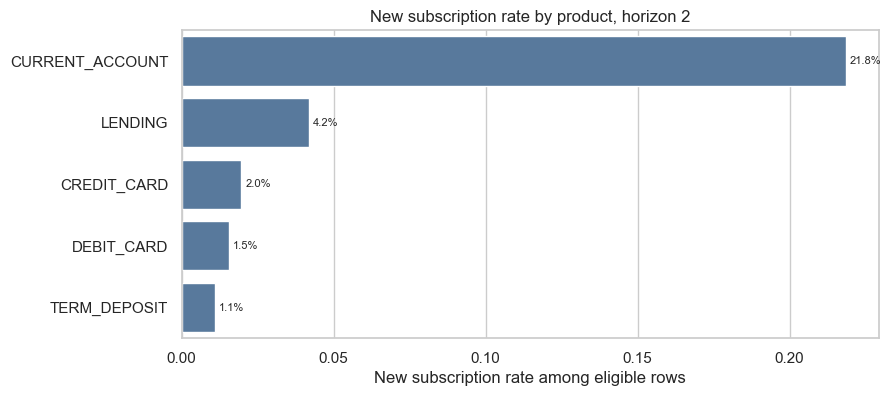

,MONTH,PRODUCT_NAME,rows,owned,ownership_rate
0,2019-01-31,CREDIT_CARD,9539,1740,0.182409
1,2019-01-31,CURRENT_ACCOUNT,9539,6623,0.694308
2,2019-01-31,DEBIT_CARD,9539,3695,0.387357
3,2019-01-31,LENDING,9539,4285,0.449209
4,2019-01-31,TERM_DEPOSIT,9539,740,0.077576
5,2019-02-28,CREDIT_CARD,14414,2699,0.187249
6,2019-02-28,CURRENT_ACCOUNT,14414,10003,0.693978
7,2019-02-28,DEBIT_CARD,14414,6115,0.424240
8,2019-02-28,LENDING,14414,5855,0.406202
9,2019-02-28,TERM_DEPOSIT,14414,1471,0.102054


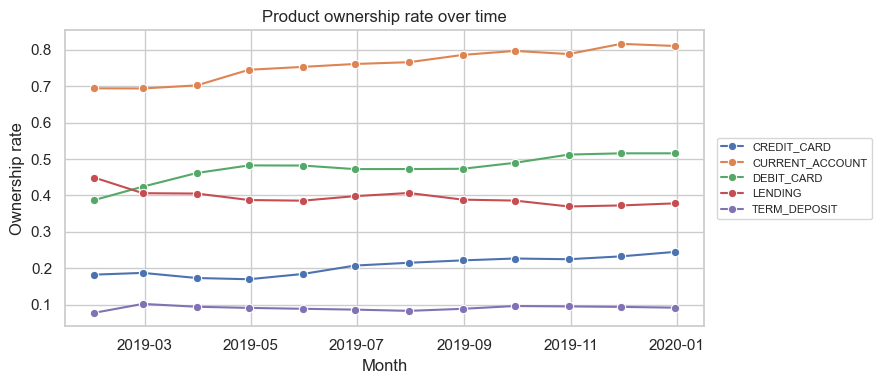

In [10]:
target_by_product = (
    subscription_long.groupby('PRODUCT_NAME')['SUBSCRIPTION']
    .agg(rows='count', positives='sum', subscription_rate='mean')
    .reset_index()
    .sort_values('subscription_rate', ascending=False)
)
target_by_product['imbalance_ratio_neg_pos'] = (target_by_product['rows'] - target_by_product['positives']) / target_by_product['positives'].replace(0, np.nan)
display(target_by_product)

plt.figure(figsize=(9, 4))
ax = sns.barplot(data=target_by_product, y='PRODUCT_NAME', x='subscription_rate', color='#4C78A8')
show_bar_labels(ax)
plt.title(f'New subscription rate by product, horizon {HORIZON}')
plt.xlabel('New subscription rate among eligible rows')
plt.ylabel('')
plt.show()

ownership_by_month = (
    feature_df[['CUSTOMER_NUMBER', 'MONTH'] + own_cols]
    .drop_duplicates()
    .melt(id_vars=['CUSTOMER_NUMBER', 'MONTH'], value_vars=own_cols, var_name='OWN_COL', value_name='OWNS_PRODUCT_T')
    .merge(PRODUCTS[['OWN_COL', 'PRODUCT_NAME']], on='OWN_COL', how='left')
    .groupby(['MONTH', 'PRODUCT_NAME'])['OWNS_PRODUCT_T']
    .agg(rows='count', owned='sum', ownership_rate='mean')
    .reset_index()
)
display(ownership_by_month)
fig, ax = plt.subplots(figsize=(11, 4))
sns.lineplot(data=ownership_by_month, x='MONTH', y='ownership_rate', hue='PRODUCT_NAME', marker='o', ax=ax)
ax.set_title('Product ownership rate over time')
ax.set_xlabel('Month')
ax.set_ylabel('Ownership rate')
ax.legend(title=None, fontsize=8, loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

### 8.2 Customer Profile Analysis



,CLIENT_SEX,PRODUCT_NAME,rows,positives,new_subscription_rate
0,F,CREDIT_CARD,192369,3707,0.019270
1,F,CURRENT_ACCOUNT,59352,11654,0.196354
2,F,DEBIT_CARD,128568,2071,0.016108
3,F,LENDING,160025,6795,0.042462
4,F,TERM_DEPOSIT,211677,3505,0.016558
5,M,CREDIT_CARD,272268,5392,0.019804
6,M,CURRENT_ACCOUNT,69466,16492,0.237411
7,M,DEBIT_CARD,177544,2662,0.014993
8,M,LENDING,193060,7984,0.041355
9,M,TERM_DEPOSIT,323451,2295,0.007095


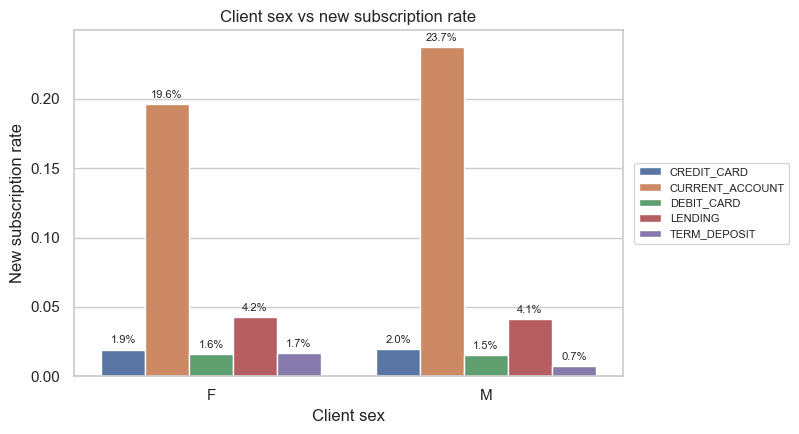

In [11]:
sex_rate = (
    subscription_long.assign(CLIENT_SEX=subscription_long['CLIENT_SEX'].fillna('UNKNOWN'))
    .groupby(['CLIENT_SEX', 'PRODUCT_NAME'], observed=False)['SUBSCRIPTION']
    .agg(rows='count', positives='sum', new_subscription_rate='mean')
    .reset_index()
)
display(sex_rate)

plt.figure(figsize=(10, 4.5))
ax = sns.barplot(data=sex_rate, x='CLIENT_SEX', y='new_subscription_rate', hue='PRODUCT_NAME')
show_bar_labels(ax, fmt='{:.1%}')
plt.title('Client sex vs new subscription rate')
plt.xlabel('Client sex')
plt.ylabel('New subscription rate')
plt.legend(title=None, fontsize=8, loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

,SUBSCRIPTION,AGE_CLEAN_mean,AGE_CLEAN_median,CUSTOMER_TENURE_MONTHS_mean,CUSTOMER_TENURE_MONTHS_median,IB_TENURE_MONTHS_mean,IB_TENURE_MONTHS_median,SPTC_COUNT_mean,SPTC_COUNT_median,TOTAL_DEPOSIT_BALANCE_mean,TOTAL_DEPOSIT_BALANCE_median,TRANS_RECORDS_mean,TRANS_RECORDS_median,TRANS_AMOUNT_SUM_mean,TRANS_AMOUNT_SUM_median,TRANS_ACTIVE_DAYS_mean,TRANS_ACTIVE_DAYS_median,ACTIVITY_RECORDS_mean,ACTIVITY_RECORDS_median,ACTIVITY_ACTIVE_DAYS_mean,ACTIVITY_ACTIVE_DAYS_median,DEVICE_NUNIQUE_mean,DEVICE_NUNIQUE_median,MERCHANT_NUNIQUE_mean,MERCHANT_NUNIQUE_median
0,0,32.448547,30.499659,3.165181,2.661191,2.239552,1.544148,1.832916,2.0,3.342822e+07,250000.0,1.273538,0.0,1.157913e+07,0.0,0.914289,0.0,1.175536,0.0,0.809910,0.0,0.0,0.0,0.0,0.0
1,1,32.168568,30.245037,1.479312,0.558522,0.794800,0.098563,1.344102,1.0,4.795531e+07,0.0,0.711527,0.0,9.137076e+06,0.0,0.518727,0.0,0.817862,0.0,0.554806,0.0,0.0,0.0,0.0,0.0


,SPTC_COUNT,PRODUCT_NAME,rows,positives,subscription_rate
0,0,CREDIT_CARD,1347,39,0.028953
1,0,CURRENT_ACCOUNT,1244,321,0.258039
2,0,DEBIT_CARD,1349,84,0.062268
3,0,LENDING,1336,55,0.041168
4,0,TERM_DEPOSIT,1308,125,0.095566
5,1,CREDIT_CARD,93905,1415,0.015068
6,1,CURRENT_ACCOUNT,72686,25533,0.351278
7,1,DEBIT_CARD,83311,2589,0.031076
8,1,LENDING,110019,11367,0.103319
9,1,TERM_DEPOSIT,103138,2120,0.020555


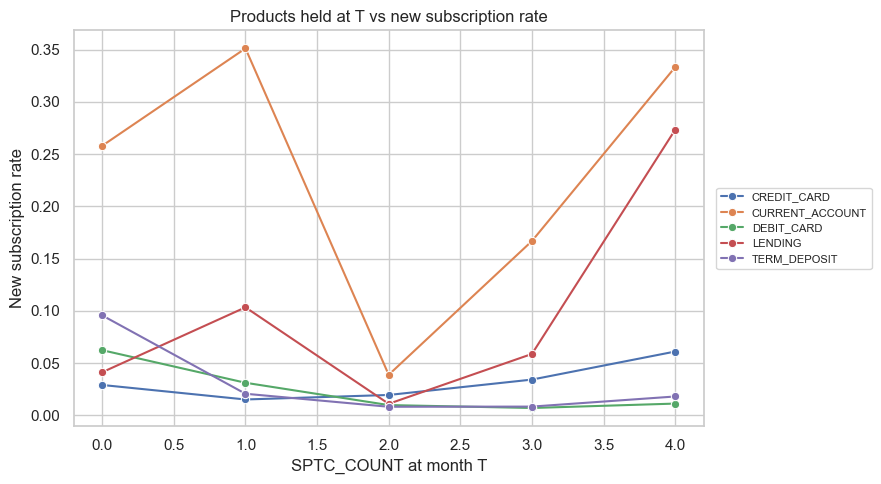

In [12]:
profile_numeric = [
    'AGE_CLEAN', 'CUSTOMER_TENURE_MONTHS', 'IB_TENURE_MONTHS', 'SPTC_COUNT',
    'TOTAL_DEPOSIT_BALANCE', 'TRANS_RECORDS', 'TRANS_AMOUNT_SUM', 'TRANS_ACTIVE_DAYS',
    'ACTIVITY_RECORDS', 'ACTIVITY_ACTIVE_DAYS', 'DEVICE_NUNIQUE', 'MERCHANT_NUNIQUE'
]
profile_compare = subscription_long.groupby('SUBSCRIPTION')[profile_numeric].agg(['mean', 'median']).reset_index()
profile_compare.columns = ['_'.join([str(x) for x in col if str(x)]) for col in profile_compare.columns]
display(profile_compare)

sptc_rate = subscription_long.groupby(['SPTC_COUNT', 'PRODUCT_NAME'])['SUBSCRIPTION'].agg(rows='count', positives='sum', subscription_rate='mean').reset_index()
display(sptc_rate.head(20))
fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=sptc_rate, x='SPTC_COUNT', y='subscription_rate', hue='PRODUCT_NAME', marker='o', ax=ax)
ax.set_title('Products held at T vs new subscription rate')
ax.set_xlabel('SPTC_COUNT at month T')
ax.set_ylabel('New subscription rate')
ax.legend(title=None, fontsize=8, loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

### 8.3. Segment Analysis



,AGE_GROUP,PRODUCT_NAME,rows,positives,subscription_rate
0,<=25,CREDIT_CARD,119932,733,0.006112
1,<=25,CURRENT_ACCOUNT,22322,10638,0.476570
2,<=25,DEBIT_CARD,19977,794,0.039746
3,<=25,LENDING,115838,1065,0.009194
4,<=25,TERM_DEPOSIT,122613,775,0.006321
5,26-35,CREDIT_CARD,192469,4128,0.021448
6,26-35,CURRENT_ACCOUNT,66631,11423,0.171437
7,26-35,DEBIT_CARD,141836,2197,0.015490
8,26-35,LENDING,152787,8172,0.053486
9,26-35,TERM_DEPOSIT,237922,2632,0.011062


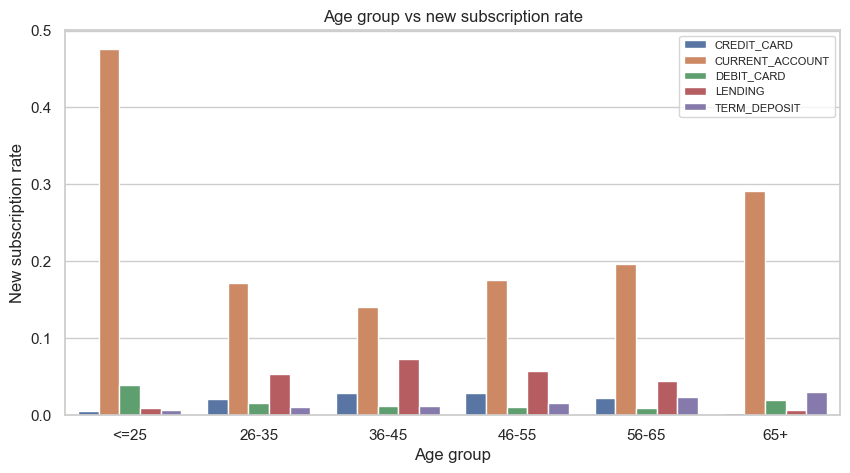

,segment_variable
0,Occupation_Group


,segment,rows,positives,subscription_rate
0,UNKNOWN,1787780,62557,0.034991


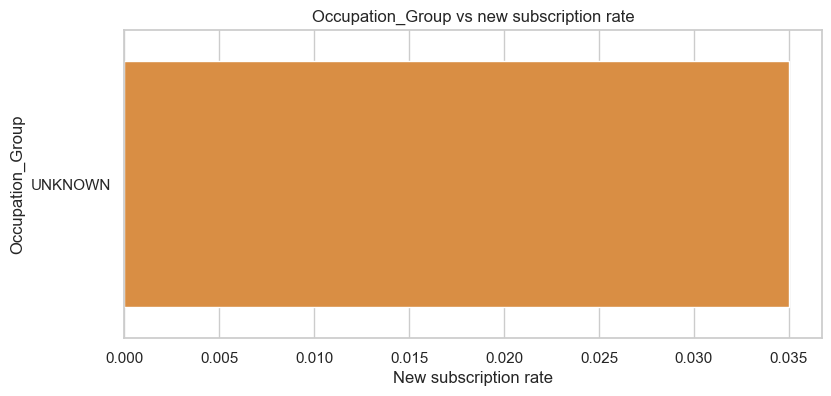

,segment_variable
0,Education_Level


,segment,rows,positives,subscription_rate
0,UNKNOWN,1787780,62557,0.034991


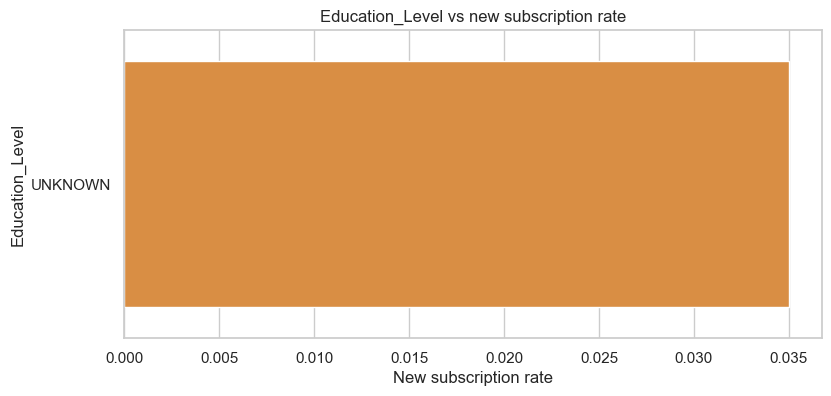

,segment_variable
0,Marital_Status


,segment,rows,positives,subscription_rate
0,UNKNOWN,1787780,62557,0.034991


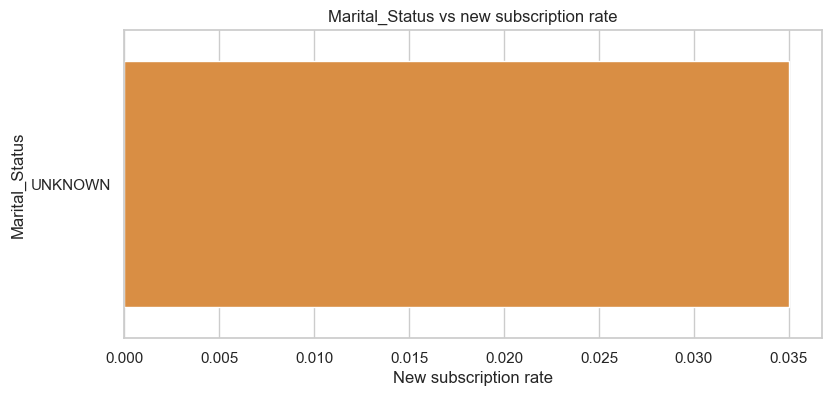

In [13]:
age_rate = subscription_long.groupby(['AGE_GROUP', 'PRODUCT_NAME'], observed=False)['SUBSCRIPTION'].agg(rows='count', positives='sum', subscription_rate='mean').reset_index()
display(age_rate)
plt.figure(figsize=(10, 5))
sns.barplot(data=age_rate, x='AGE_GROUP', y='subscription_rate', hue='PRODUCT_NAME')
plt.title('Age group vs new subscription rate')
plt.xlabel('Age group')
plt.ylabel('New subscription rate')
plt.legend(fontsize=8)
plt.show()

for col in ['Occupation_Group', 'Education_Level', 'Marital_Status']:
    segment = (
        subscription_long.assign(segment=subscription_long[col].astype('string').fillna('UNKNOWN'))
        .groupby('segment')['SUBSCRIPTION']
        .agg(rows='count', positives='sum', subscription_rate='mean')
        .reset_index()
        .query('rows >= 1000')
        .sort_values('subscription_rate', ascending=False)
        .head(15)
    )
    display(pd.DataFrame({'segment_variable': [col]}))
    display(segment)
    plt.figure(figsize=(9, 4))
    sns.barplot(data=segment, y='segment', x='subscription_rate', color='#F28E2B')
    plt.title(f'{col} vs new subscription rate')
    plt.xlabel('New subscription rate')
    plt.ylabel(col)
    plt.show()

### 8.4 Product Co-occurrence vÃ  Transition Signal



PRODUCT_NAME,CURRENT_ACCOUNT,TERM_DEPOSIT,CREDIT_CARD,DEBIT_CARD,LENDING
PRODUCT_NAME,,,,,
CURRENT_ACCOUNT,1.000000,-0.008791,-0.497631,0.279584,-0.119188
TERM_DEPOSIT,-0.008791,1.000000,-0.046587,-0.118044,-0.147003
CREDIT_CARD,-0.497631,-0.046587,1.000000,-0.444968,0.476165
DEBIT_CARD,0.279584,-0.118044,-0.444968,1.000000,-0.576368
LENDING,-0.119188,-0.147003,0.476165,-0.576368,1.000000


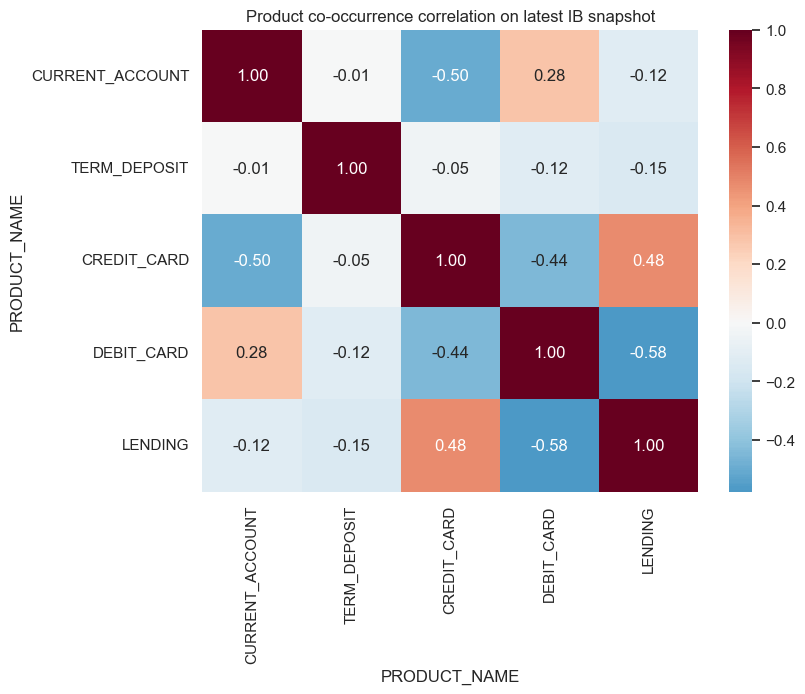

,CURRENT_PRODUCT,NEXT_PRODUCT,subscribers_with_current_product,subscribers,share_among_subscribers
10,CURRENT_ACCOUNT,CREDIT_CARD,8283,9099,0.910320
5,CURRENT_ACCOUNT,TERM_DEPOSIT,4971,5800,0.857069
15,CURRENT_ACCOUNT,DEBIT_CARD,3784,4733,0.799493
3,DEBIT_CARD,CURRENT_ACCOUNT,20255,28146,0.719640
22,CREDIT_CARD,LENDING,10548,14779,0.713715
14,LENDING,CREDIT_CARD,5891,9099,0.647434
8,DEBIT_CARD,TERM_DEPOSIT,2943,5800,0.507414
19,LENDING,DEBIT_CARD,1667,4733,0.352208
20,CURRENT_ACCOUNT,LENDING,4660,14779,0.315312
13,DEBIT_CARD,CREDIT_CARD,2479,9099,0.272448


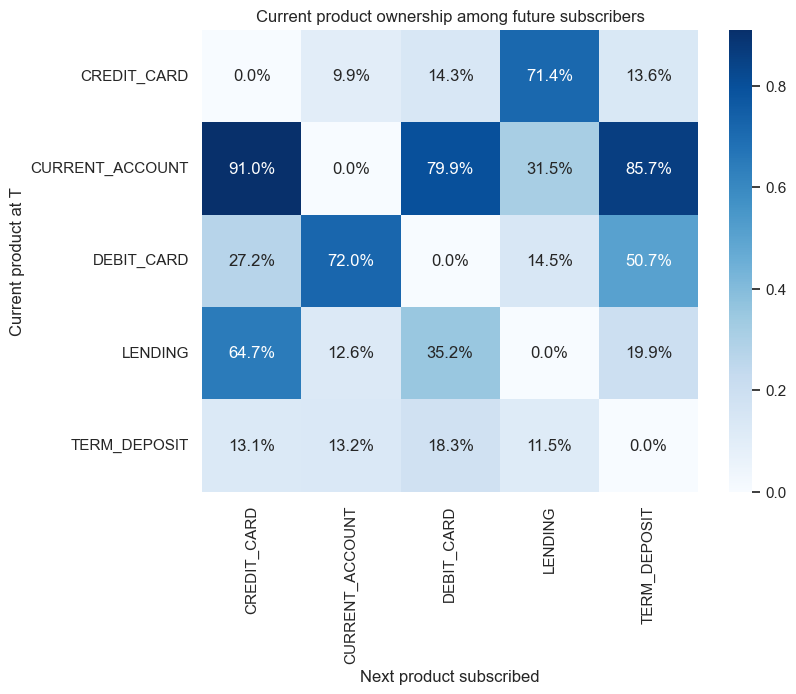

In [14]:
latest_ib = feature_df.sort_values('MONTH').groupby('CUSTOMER_NUMBER', as_index=False).tail(1)
latest_co_matrix = latest_ib[own_cols].corr()
latest_co_matrix.index = PRODUCTS['PRODUCT_NAME']
latest_co_matrix.columns = PRODUCTS['PRODUCT_NAME']
display(latest_co_matrix)
plt.figure(figsize=(8, 6))
sns.heatmap(latest_co_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Product co-occurrence correlation on latest IB snapshot')
plt.show()

transition_rows = []
for product_name, own_col in PRODUCTS[['PRODUCT_NAME', 'OWN_COL']].itertuples(index=False):
    rows = subscription_long.query('SUBSCRIPTION == 1 and PRODUCT_NAME == @product_name').copy()
    for current_product_name, current_own_col in PRODUCTS[['PRODUCT_NAME', 'OWN_COL']].itertuples(index=False):
        transition_rows.append({
            'CURRENT_PRODUCT': current_product_name,
            'NEXT_PRODUCT': product_name,
            'subscribers_with_current_product': int(rows[current_own_col].sum()),
            'subscribers': len(rows),
            'share_among_subscribers': float(rows[current_own_col].mean()) if len(rows) else np.nan,
        })
transition_signal = pd.DataFrame(transition_rows)
display(transition_signal.sort_values('share_among_subscribers', ascending=False).head(25))
transition_pivot = transition_signal.pivot(index='CURRENT_PRODUCT', columns='NEXT_PRODUCT', values='share_among_subscribers')
plt.figure(figsize=(8, 6))
sns.heatmap(transition_pivot, annot=True, fmt='.1%', cmap='Blues')
plt.title('Current product ownership among future subscribers')
plt.xlabel('Next product subscribed')
plt.ylabel('Current product at T')
plt.show()

### 8.5 Behavior Analysis



,feature,bucket,rows,positives,subscription_rate
0,TRANS_RECORDS,Low,446945,17202,0.038488
1,TRANS_RECORDS,Medium low,446945,17422,0.038980
2,TRANS_RECORDS,Medium high,446945,17358,0.038837
3,TRANS_RECORDS,High,446945,10575,0.023661
4,ACTIVITY_RECORDS,Low,446945,16359,0.036602
5,ACTIVITY_RECORDS,Medium low,446945,16416,0.036729
6,ACTIVITY_RECORDS,Medium high,446945,16359,0.036602
7,ACTIVITY_RECORDS,High,446945,13423,0.030033
8,ACTIVITY_ACTIVE_DAYS,Low,446945,16359,0.036602
9,ACTIVITY_ACTIVE_DAYS,Medium low,446945,16416,0.036729


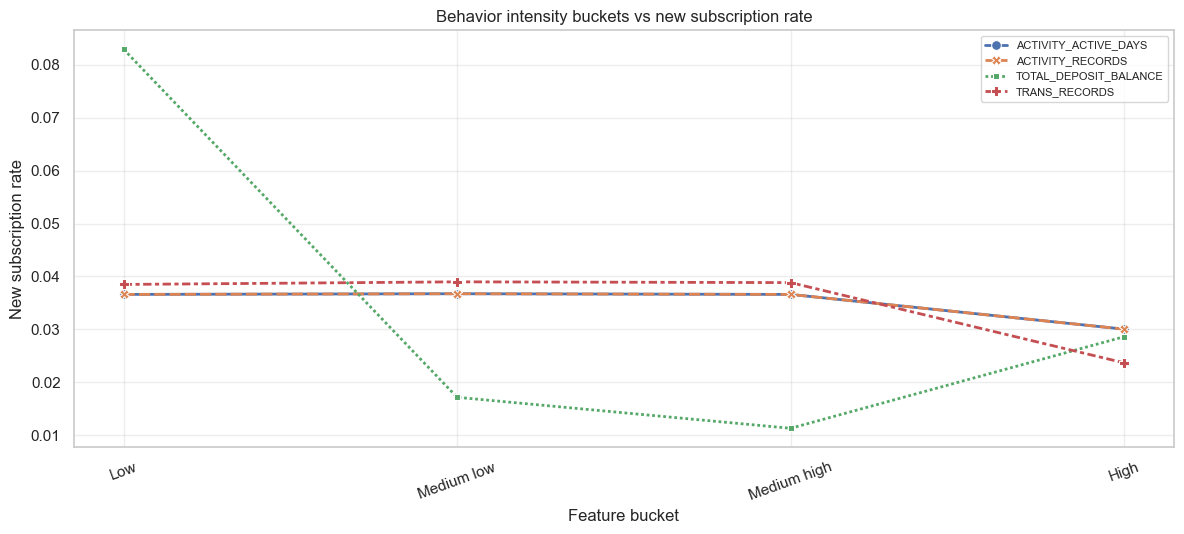

In [15]:
behavior_features = [
    'TRANS_RECORDS', 'ACTIVITY_RECORDS', 'ACTIVITY_ACTIVE_DAYS', 'TOTAL_DEPOSIT_BALANCE'
]
behavior_bucket_order = ['Low', 'Medium low', 'Medium high', 'High']
behavior_rows = []
for col in behavior_features:
    values = pd.to_numeric(subscription_long[col], errors='coerce').fillna(0)
    try:
        buckets = pd.qcut(values.rank(method='first'), q=4, labels=behavior_bucket_order)
    except Exception:
        buckets = pd.cut(values, bins=4, labels=behavior_bucket_order)
    tmp = (
        subscription_long.assign(feature=col, bucket=buckets)
        .groupby(['feature', 'bucket'], observed=False)['SUBSCRIPTION']
        .agg(rows='count', positives='sum', subscription_rate='mean')
        .reset_index()
    )
    behavior_rows.append(tmp)
behavior_bucket = pd.concat(behavior_rows, ignore_index=True)
behavior_bucket['bucket'] = pd.Categorical(behavior_bucket['bucket'], categories=behavior_bucket_order, ordered=True)
display(behavior_bucket)

fig, ax = plt.subplots(figsize=(12, 5.5))
plot_data = behavior_bucket.sort_values(['feature', 'bucket']).copy()

sns.lineplot(
    data=plot_data,
    x='bucket',
    y='subscription_rate',
    hue='feature',
    style='feature',
    markers=True,
    dashes=True,
    estimator=None,
    linewidth=2,
    markersize=7,
    ax=ax,
)
ax.set_title('Behavior intensity buckets vs new subscription rate')
ax.set_xlabel('Feature bucket')
ax.set_ylabel('New subscription rate')
ax.tick_params(axis='x', rotation=20)
ax.grid(True, axis='both', alpha=0.35)
ax.legend(fontsize=8, title=None)
plt.tight_layout()
plt.show()

### 8.6 Feature Candidate Screen



,feature,missing_rate,zero_rate,nunique,mean_subscribed,mean_not_subscribed,median_subscribed,median_not_subscribed,abs_mean_diff,corr_with_subscription,abs_corr_with_subscription
3,SPTC_COUNT,0.00000,0.003683,5,1.344102e+00,1.832916e+00,1.000000,2.000000,4.888133e-01,-0.155751,0.155751
1,CUSTOMER_TENURE_MONTHS,0.00000,0.006336,304,1.479312e+00,3.165181e+00,0.558522,2.661191,1.685869e+00,-0.131177,0.131177
2,IB_TENURE_MONTHS,0.00000,0.253791,303,7.947996e-01,2.239552e+00,0.098563,1.544148,1.444752e+00,-0.113681,0.113681
5,TOTAL_DEPOSIT_ACCTS,0.00000,0.228083,33,5.285739e-01,8.827491e-01,0.000000,1.000000,3.541752e-01,-0.088428,0.088428
11,TRANS_ACTIVE_DAYS,0.00000,0.815356,32,5.187269e-01,9.142888e-01,0.000000,0.000000,3.955618e-01,-0.026371,0.026371
7,TRANS_RECORDS,0.00000,0.815356,191,7.115271e-01,1.273538e+00,0.000000,0.000000,5.620109e-01,-0.019634,0.019634
13,ACTIVITY_ACTIVE_DAYS,0.00000,0.844153,32,5.548060e-01,8.099104e-01,0.000000,0.000000,2.551044e-01,-0.018174,0.018174
12,ACTIVITY_RECORDS,0.00000,0.844153,161,8.178621e-01,1.175536e+00,0.000000,0.000000,3.576741e-01,-0.014231,0.014231
16,AVG_LOAN_AMOUNT,0.00000,0.655408,109410,1.275323e+08,1.545076e+08,0.000000,0.000000,2.697526e+07,-0.012305,0.012305
4,TOTAL_DEPOSIT_BALANCE,0.00000,0.228083,360959,4.795531e+07,3.342822e+07,0.000000,250000.000000,1.452710e+07,0.007698,0.007698


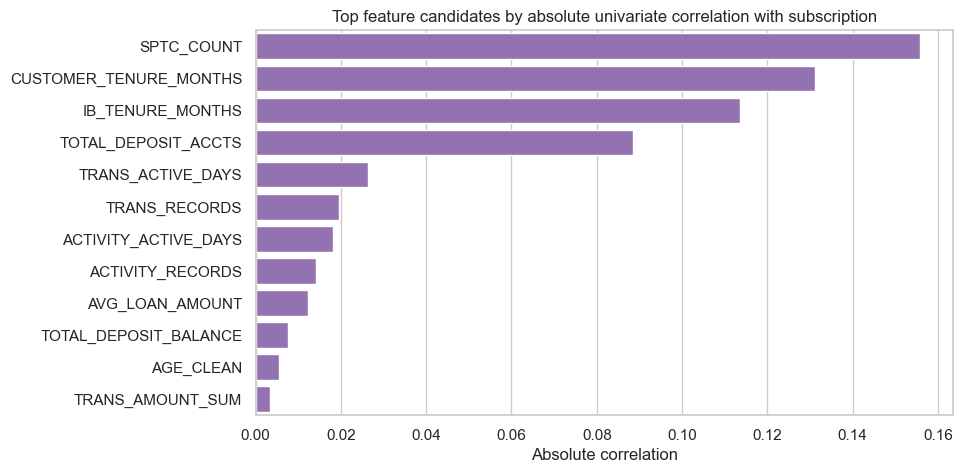

In [16]:
screen_cols = [
    'AGE_CLEAN', 'CUSTOMER_TENURE_MONTHS', 'IB_TENURE_MONTHS', 'SPTC_COUNT',
    'TOTAL_DEPOSIT_BALANCE', 'TOTAL_DEPOSIT_ACCTS', 'CARD_UTILIZATION',
    'TRANS_RECORDS', 'TRANS_AMOUNT_SUM', 'TRANS_AMOUNT_MEAN', 'TRANS_AMOUNT_MAX',
    'TRANS_ACTIVE_DAYS', 'ACTIVITY_RECORDS', 'ACTIVITY_ACTIVE_DAYS',
    'DEVICE_NUNIQUE', 'MERCHANT_NUNIQUE', 'AVG_LOAN_AMOUNT',
    'LIMIT_AMT_CREDIT', 'OUTSTANDING_BAL_CREDIT',
]
y = subscription_long['SUBSCRIPTION'].astype(int)
rows = []
for col in screen_cols:
    values = pd.to_numeric(subscription_long[col], errors='coerce').replace([np.inf, -np.inf], np.nan)
    rows.append({
        'feature': col,
        'missing_rate': float(values.isna().mean()),
        'zero_rate': float((values.fillna(0) == 0).mean()),
        'nunique': int(values.nunique(dropna=True)),
        'mean_subscribed': float(values[y == 1].mean()),
        'mean_not_subscribed': float(values[y == 0].mean()),
        'median_subscribed': float(values[y == 1].median()),
        'median_not_subscribed': float(values[y == 0].median()),
        'abs_mean_diff': float(abs(values[y == 1].mean() - values[y == 0].mean())),
        'corr_with_subscription': float(values.corr(y)),
    })
feature_screen = pd.DataFrame(rows)
feature_screen['abs_corr_with_subscription'] = feature_screen['corr_with_subscription'].abs()
feature_screen = feature_screen.sort_values(['abs_corr_with_subscription', 'abs_mean_diff'], ascending=False)
display(feature_screen)

plt.figure(figsize=(9, 5))
sns.barplot(data=feature_screen.head(12), y='feature', x='abs_corr_with_subscription', color='#9467BD')
plt.title('Top feature candidates by absolute univariate correlation with subscription')
plt.xlabel('Absolute correlation')
plt.ylabel('')
plt.show()

## 9. Save Model Input

Export exactly one model input parquet for the modeling notebook.

In [17]:
output_path = OUTPUT_DIR / 'gcon_model_input.parquet'
save_parquet(model_input, output_path)
display(pd.DataFrame({
    'output_path': [str(output_path)],
    'rows': [len(model_input)],
    'features': [len([c for c in model_input.columns if c not in ['CUSTOMER_NUMBER', 'PRODUCT_CODE', 'PRODUCT_NAME', 'MONTH', 'SUBSCRIPTION']])],
    'positive_rate': [model_input['SUBSCRIPTION'].mean()],
    'min_month': [model_input['MONTH'].min()],
    'max_month': [model_input['MONTH'].max()],
}))

saved c:\Users\bumbu\Documents\gconlap\gcon\NBFO_IB\processed_data\gcon_model_input.parquet (1787780, 122)


,output_path,rows,features,positive_rate,min_month,max_month
0,c:\Users\bumbu\Documents\gconlap\gcon\NBFO_IB\...,1787780,117,0.034991,2019-01-31,2019-10-31
